# 🤖 Notebook 3: Demand Prediction Agent
**Project**: Agentic AI-Based Dynamic Tariff Optimization for EV Charging Networks  
**Team**: Socbiz Analytics | OP'26  

---

## Overview
This agent predicts charging demand (station utilisation rate) 5-minutes ahead using historical session data.  
Four ML models are trained; the best is selected by R² on a **temporal hold-out** test set.

### Outputs
| Output | Description |
|--------|-------------|
| `predicted_utilization` | Expected charger utilisation rate [0,1] |
| `congestion_probability` | P(utilisation > 80%) — binary classifier |

### Metrics Tracked
- **RMSE** – Penalises large prediction errors  
- **MAE** – Mean absolute error across time slots  
- **R²** – Variance explained by the model  


In [1]:
import pandas as pd
import numpy as np
import os, warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

BASE_DIR    = "/Users/saksham56/Desktop/open-projects/Socbiz Analytics Project"
PROC_DIR    = os.path.join(BASE_DIR, "data", "processed")
RESULTS_DIR = os.path.join(BASE_DIR, "outputs", "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

# Optional boosting libs
try:
    import xgboost as xgb
    HAS_XGB = True
    print("✓ XGBoost available")
except ImportError:
    HAS_XGB = False
    print("✗ XGBoost not available — will skip")

try:
    import lightgbm as lgb
    HAS_LGB = True
    print("✓ LightGBM available")
except ImportError:
    HAS_LGB = False
    print("✗ LightGBM not available — will skip")

print("\nLoading ST-EVCDP panel data ...")
df = pd.read_csv(os.path.join(PROC_DIR, "stevcdp_panel.csv"), low_memory=False)
df['datetime'] = pd.to_datetime(df['datetime'])
print(f"  Shape: {df.shape}")


✓ XGBoost available
✓ LightGBM available

Loading ST-EVCDP panel data ...


  Shape: (2134080, 28)


## Feature Engineering — Lag & Rolling Features

In [2]:
# Sort by grid then time so lag/rolling are computed correctly
df = df.sort_values(['grid_id','datetime']).reset_index(drop=True)

# Target
TARGET = 'charger_utilization_rate'

# Lag features (per grid)
df['lag_1']  = df.groupby('grid_id')[TARGET].shift(1)
df['lag_3']  = df.groupby('grid_id')[TARGET].shift(3)
df['lag_6']  = df.groupby('grid_id')[TARGET].shift(6)
df['lag_12'] = df.groupby('grid_id')[TARGET].shift(12)   # 1 hour

# Rolling statistics (per grid)
df['roll_mean_12'] = df.groupby('grid_id')[TARGET].transform(lambda x: x.shift(1).rolling(12).mean())
df['roll_std_12']  = df.groupby('grid_id')[TARGET].transform(lambda x: x.shift(1).rolling(12).std())
df['roll_max_12']  = df.groupby('grid_id')[TARGET].transform(lambda x: x.shift(1).rolling(12).max())

FEATURES = [
    'hour', 'day_of_week', 'is_weekend', 'is_peak',
    'occupancy_density', 'energy_kwh', 'price_multiplier',
    'lag_1', 'lag_3', 'lag_6', 'lag_12',
    'roll_mean_12', 'roll_std_12', 'roll_max_12'
]

df = df.dropna(subset=FEATURES + [TARGET])
print(f"After lag feature creation and dropna: {df.shape}")


After lag feature creation and dropna: (2131116, 35)


## Temporal Train/Test Split

In [3]:
# 80/20 temporal split — NO shuffling (prevents data leakage)
cutoff = df['datetime'].quantile(0.80)
print(f"Train/test cutoff: {cutoff}")

train = df[df['datetime'] < cutoff]
test  = df[df['datetime'] >= cutoff]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

# Congestion label: 1 if utilisation > 80%
SURGE_THRESH = 0.80
y_train_clf = (y_train >= SURGE_THRESH).astype(int)
y_test_clf  = (y_test  >= SURGE_THRESH).astype(int)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Congestion positive rate — Train: {y_train_clf.mean():.2%}  Test: {y_test_clf.mean():.2%}")


Train/test cutoff: 2022-07-13 00:10:00


Train: 1,704,794  |  Test: 426,322
Congestion positive rate — Train: 1.08%  Test: 1.04%


## Model Training — Utilisation Regression

In [4]:
models, preds, metrics_rows = {}, {}, []

def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"  {name:<28} RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

print("Training regressors ...\n")

# 1. Random Forest
print("  [1/4] Random Forest ...")
rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
models['RandomForest'] = rf
preds['RandomForest']  = rf_pred
metrics_rows.append(evaluate('RandomForest', y_test, rf_pred))

# 2. XGBoost
if HAS_XGB:
    print("  [2/4] XGBoost ...")
    xgb_m = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05,
                               subsample=0.8, random_state=42, n_jobs=-1, verbosity=0)
    xgb_m.fit(X_train, y_train)
    xgb_pred = xgb_m.predict(X_test)
    models['XGBoost'] = xgb_m
    preds['XGBoost']  = xgb_pred
    metrics_rows.append(evaluate('XGBoost', y_test, xgb_pred))
else:
    print("  [2/4] XGBoost — skipped")

# 3. LightGBM
if HAS_LGB:
    print("  [3/4] LightGBM ...")
    lgb_m = lgb.LGBMRegressor(n_estimators=200, max_depth=8, learning_rate=0.05,
                                subsample=0.8, random_state=42, n_jobs=-1, verbosity=-1)
    lgb_m.fit(X_train, y_train)
    lgb_pred = lgb_m.predict(X_test)
    models['LightGBM'] = lgb_m
    preds['LightGBM']  = lgb_pred
    metrics_rows.append(evaluate('LightGBM', y_test, lgb_pred))
else:
    print("  [3/4] LightGBM — skipped")

# 4. HistGradientBoosting (sklearn built-in, no extra deps)
print("  [4/4] HistGradientBoosting ...")
hgb = HistGradientBoostingRegressor(max_iter=200, max_depth=8, learning_rate=0.05, random_state=42)
hgb.fit(X_train, y_train)
hgb_pred = hgb.predict(X_test)
models['HistGBM'] = hgb
preds['HistGBM']  = hgb_pred
metrics_rows.append(evaluate('HistGBM', y_test, hgb_pred))


Training regressors ...

  [1/4] Random Forest ...


  RandomForest                 RMSE=0.0121  MAE=0.0046  R²=0.9953
  [2/4] XGBoost ...


  XGBoost                      RMSE=0.0128  MAE=0.0053  R²=0.9947
  [3/4] LightGBM ...


  LightGBM                     RMSE=0.0127  MAE=0.0051  R²=0.9949
  [4/4] HistGradientBoosting ...


  HistGBM                      RMSE=0.0131  MAE=0.0053  R²=0.9945


## Model Comparison & Best Model Selection


── Model Comparison ────────────────────────────────────
       Model     RMSE      MAE       R2
RandomForest 0.012124 0.004627 0.995299
     XGBoost 0.012826 0.005254 0.994738
    LightGBM 0.012687 0.005075 0.994852
     HistGBM 0.013100 0.005298 0.994511

  ✓ Best model by R²: RandomForest


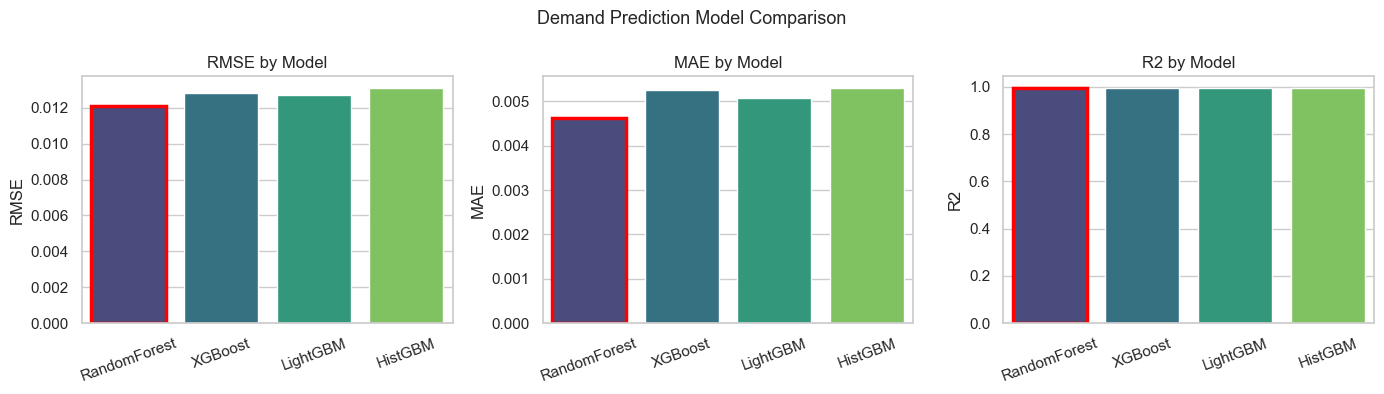

In [5]:
metrics_df = pd.DataFrame(metrics_rows)
best_idx   = metrics_df['R2'].idxmax()
BEST_NAME  = metrics_df.loc[best_idx, 'Model']

print("\n── Model Comparison ────────────────────────────────────")
print(metrics_df.to_string(index=False))
print(f"\n  ✓ Best model by R²: {BEST_NAME}")

metrics_df.to_csv(os.path.join(RESULTS_DIR, "model_metrics.csv"), index=False)

# Visualise metrics
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ['RMSE','MAE','R2']):
    bars = sns.barplot(data=metrics_df, x='Model', y=metric,
                       palette='viridis', ax=ax)
    ax.set_title(f'{metric} by Model')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    # Highlight best
    best_val = metrics_df.loc[best_idx, metric]
    for patch, val in zip(bars.patches, metrics_df[metric]):
        if abs(val - best_val) < 1e-8:
            patch.set_edgecolor('red')
            patch.set_linewidth(2.5)
plt.suptitle('Demand Prediction Model Comparison', fontsize=13)
plt.tight_layout()
plt.show()


## Congestion Classifier (P(util > 80%))

In [6]:
from sklearn.metrics import roc_auc_score, classification_report

print("Training Congestion Classifier ...")

if HAS_LGB:
    clf = lgb.LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                              random_state=42, n_jobs=-1, verbosity=-1)
else:
    clf = HistGradientBoostingClassifier(max_iter=100, max_depth=6,
                                         learning_rate=0.1, random_state=42)

clf.fit(X_train, y_train_clf)
y_prob = clf.predict_proba(X_test)[:, 1]
y_pred_clf = (y_prob >= 0.5).astype(int)

roc = roc_auc_score(y_test_clf, y_prob)
print(f"  ROC-AUC: {roc:.4f}")
print(classification_report(y_test_clf, y_pred_clf, target_names=['Normal','Congested']))


Training Congestion Classifier ...


  ROC-AUC: 1.0000
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    421890
   Congested       0.98      0.98      0.98      4432

    accuracy                           1.00    426322
   macro avg       0.99      0.99      0.99    426322
weighted avg       1.00      1.00      1.00    426322



## Save Demand Predictions

In [7]:
best_reg  = models[BEST_NAME]
best_pred = preds[BEST_NAME]

out_df = test[['datetime','grid_id','charger_utilization_rate','energy_kwh']].copy()
out_df = out_df.rename(columns={'charger_utilization_rate': 'actual_utilization'})
out_df['predicted_utilization']  = np.clip(best_pred, 0, 1)
out_df['congestion_probability'] = y_prob

out_path = os.path.join(RESULTS_DIR, "demand_predictions.csv")
out_df.to_csv(out_path, index=False)
print(f"✓ Demand predictions saved → {out_path}  shape={out_df.shape}")


✓ Demand predictions saved → /Users/saksham56/Desktop/open-projects/Socbiz Analytics Project/outputs/results/demand_predictions.csv  shape=(426322, 6)


## Feature Importance

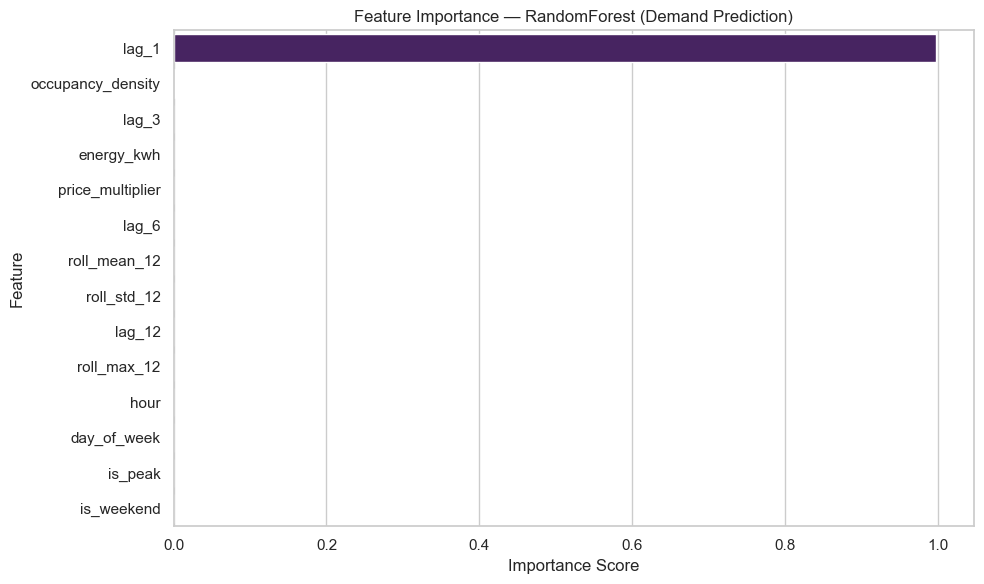


── Top 5 features ──
  lag_1                  0.99733
  occupancy_density      0.00149
  lag_3                  0.00058
  energy_kwh             0.00030
  price_multiplier       0.00010


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

if BEST_NAME in ('RandomForest', 'XGBoost', 'LightGBM'):
    importances = best_reg.feature_importances_
    feat_imp = pd.Series(importances, index=FEATURES).sort_values(ascending=False)
else:
    # HistGBM: use permutation importance on a small sample
    from sklearn.inspection import permutation_importance
    sample_idx = np.random.default_rng(42).choice(len(X_test), size=min(3000, len(X_test)), replace=False)
    perm = permutation_importance(best_reg, X_test.iloc[sample_idx], y_test.iloc[sample_idx],
                                  n_repeats=5, random_state=42, n_jobs=-1)
    feat_imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=False)

sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis', ax=ax)
ax.set_title(f'Feature Importance — {BEST_NAME} (Demand Prediction)')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

print("\n── Top 5 features ──")
for feat, val in feat_imp.head().items():
    print(f"  {feat:<22} {val:.5f}")


## Actual vs Predicted Utilisation (Sample)

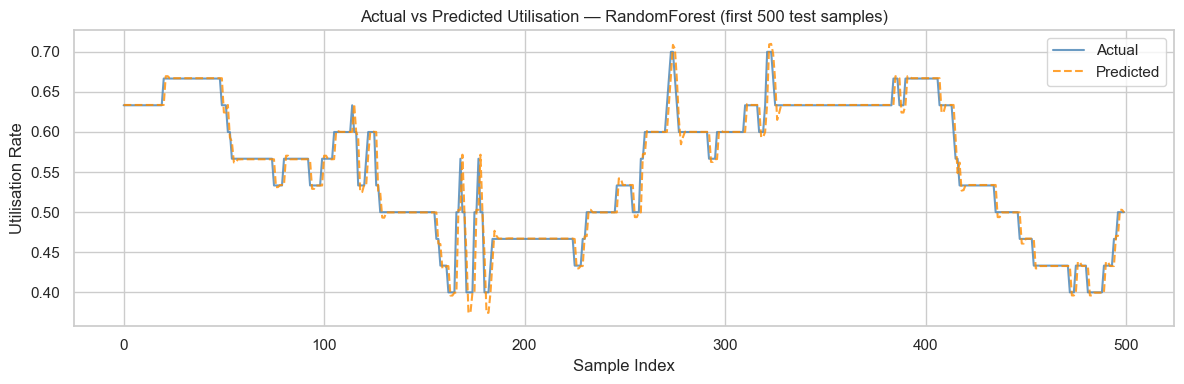


── Final Test Metrics (RandomForest) ──
  RMSE : 0.0121
  MAE  : 0.0046
  R²   : 0.9953

✓ Demand Prediction Agent completed.


In [9]:
sample_test = test.head(500).copy()
sample_pred = np.clip(best_reg.predict(sample_test[FEATURES]), 0, 1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(500), sample_test[TARGET].values, label='Actual',   color='steelblue',  alpha=0.8)
ax.plot(range(500), sample_pred,                label='Predicted', color='darkorange', alpha=0.8, linestyle='--')
ax.set_title(f'Actual vs Predicted Utilisation — {BEST_NAME} (first 500 test samples)')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Utilisation Rate')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n── Final Test Metrics ({BEST_NAME}) ──")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, best_pred)):.4f}")
print(f"  MAE  : {mean_absolute_error(y_test, best_pred):.4f}")
print(f"  R²   : {r2_score(y_test, best_pred):.4f}")
print(f"\n✓ Demand Prediction Agent completed.")
